In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools
import os

from sklearn.metrics import r2_score
from pathlib import Path

def comp_simple_preds(corrections):
    A = np.array([i["absorbance"] for i in corrections])
    f = np.array([i["load"] for i in corrections])
    
    C = A @ A.T
    C = C / np.diag(C)
    
    fhat = (C @ f - f)/(f.shape[0] - 1)
    
    return fhat, r2_score(f, fhat)

import pandas as pd

In [2]:
folders = ["../data/pfte/laboratory/ebs","../data/pfte/laboratory/map","../data/pfte/laboratory/vibes"]
wn = pd.read_parquet("../data/pfte/laboratory/spectra.parquet").columns.astype(float)

with open("../data/spectrabase/ref_dict.pkl", "rb") as f:
    ref_prof = pickle.load(f)

loads_df = pd.read_csv("../data/pfte/laboratory/loadings.csv",index_col=0)

In [3]:
paths = []
for folder in folders:
    for p in os.listdir(folder):
        paths.append(folder + "/" + p)

In [4]:
gt = ref_prof["Ammonium sulfate"]

In [34]:
for p in paths:

    with open(p, "rb") as f:
        res = pickle.load(f)

    for i in range(len(res)):
        id = res[i]["sample_id"]
        
        if id not in loads_df.index:
            continue
        
        info = loads_df.loc[id]
        res[i]["analyte"] = info["compounds"]
        
        if info["compounds"] != "Ammonium sulfate":
            res[i]["load"] = info["OC"]

        else:
            res[i]["load"] = info["AS"]
            
        try:
            gt = ref_prof[info["compounds"]]
            a = res[i]["absorbance"]
            res[i]["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
        except:
            continue

    with open(p, "wb") as f:
        pickle.dump(res,f)

In [35]:
compounds = ['12-Tricosanone', 'Ammonium sulfate', 'Suberic Acid','levoglucosan']
cors_dict = {}
for p in paths:
    with open(p, "rb") as f:
        res = pickle.load(f)

    path = Path(p)
    method = f"{path.parent.name}_{path.stem}"

    cors_dict[method] = {}
    for comp in compounds:
        cors = []
        for i in range(len(res)):
            if res[i]["analyte"] == comp:
                cors.append(res[i]["ref_corr"])
        cors_dict[method][comp] = np.array(cors)

In [36]:
average_cors = {}
for method in cors_dict:
    average_cors[method] = {}
    for comp in cors_dict[method]:
        average_cors[method][comp] = 100*np.mean(cors_dict[method][comp])
pd.DataFrame(average_cors).round(2).T.mean(axis=1)

ebs_PB_c_loo_tau_0.1         79.3500
ebs_ALS_c_bcv_tau_0.1        83.3950
ebs_PB_c_bcv_tau_0.1         79.1075
ebs_PB_c_loo_tau_bcv         82.0800
ebs_ALS_c_loo_tau_0.1        60.5750
ebs_ALS_c_bcv_tau_bcv        82.9925
ebs_ALS_c_loo_tau_bcv        64.1675
ebs_PB_c_bcv_tau_bcv         69.9900
map_PB_c_loo_tau_0.1         86.5975
map_ALS_c_bcv_tau_0.1        80.1500
map_PB_c_bcv_tau_0.1         81.4025
map_PB_c_loo_tau_bcv         85.1950
map_ALS_c_loo_tau_0.1        83.0300
map_ALS_c_bcv_tau_bcv        79.2750
map_ALS_c_loo_tau_bcv        82.7550
map_PB_c_bcv_tau_bcv         70.7700
vibes_ALS_c_elbo_tau_elbo    86.7300
vibes_PB_c_loo_tau_0.1       87.8875
vibes_PB_c_elbo_tau_0.1      88.2450
vibes_ALS_c_loo_tau_elbo     86.7100
vibes_PB_c_loo_tau_elbo      88.0750
vibes_ALS_c_elbo_tau_0.1     85.5775
vibes_ALS_c_loo_tau_0.1      85.3475
vibes_PB_c_elbo_tau_elbo     88.0900
dtype: float64

In [ ]:
PB_c_loo_tau_0.1.pkl

In [29]:
res_dict = {}

for p in paths:

    with open(p, "rb") as f:
        res = pickle.load(f)

    path = Path(p)
    method = f"{path.parent.name}_{path.stem}"

    res_dict[method] = res

In [9]:
for method in res_dict:
    break

In [10]:
cors = np.array([np.array([i["ref_corr"] for i in res_dict[method]]) for method in res_dict]).T

In [11]:
X = (cors.T - cors.mean(axis=1))/cors.std(axis=1)

In [12]:
X = X.T

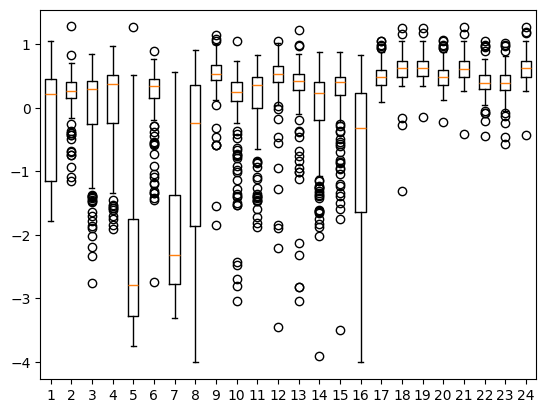

In [13]:
plt.boxplot(X)
plt.show()

In [76]:
res_dict['../data/pfte/laboratory/ebs/ALS_c_loo_tau_0.1.pkl']

[{'sample_id': '01324.dpt',
  'absorbance': array([-1.07884125e-05,  5.14850776e-06,  5.69670170e-05, ...,
          4.81597614e-05, -6.52975766e-05, -2.24626802e-04], shape=(2785,)),
  'time': 0.01452946662902832,
  'sigma': 0,
  'tau': 0.1,
  'c': np.int64(47),
  'x': array([ -1.16914426,  -2.0552179 ,  -0.12254549,  -3.29551366,
           1.59906949,   0.28729538,   0.96920108,  -4.61765838,
           9.81257554,  -3.43186479,   0.08976852,   0.21829003,
           0.44540888,  -3.25633754,  -0.81787069,  -8.42913009,
           3.92217458,   5.57495141,   7.10091267,  -8.32720782,
          -8.68664645,   5.98733314,   0.79015101,   0.08596405,
           6.56547681, -17.91296473,  -3.25580731, -15.14676489,
         -28.38558713, -22.65842295,  -4.0200429 ,  -6.21135086,
          14.60841561,  31.24534982,  -2.96394622, -23.00859643,
          30.44854957, -23.29529991,  25.85618922,  -2.1732938 ,
           0.07301161,  24.79090343, -23.97372709,   6.82637665,
          -3.490

In [75]:
res_dict['../data/pfte/laboratory/ebs/PB_c_loo_tau_0.1.pkl']

[{'sample_id': '01324.dpt',
  'absorbance': array([1.14509457e-10, 3.19258832e-05, 1.04320204e-04, ...,
         9.59772175e-05, 5.31877494e-05, 2.03636278e-05], shape=(2785,)),
  'time': 4.27434229850769,
  'sigma': 0,
  'tau': 0.1,
  'c': np.int64(47),
  'x': array([ -1.16983275,  -2.06636012,  -0.13009016,  -3.30096222,
           1.63357752,   0.360974  ,   0.92174039,  -4.68963634,
           9.9287634 ,  -3.46370549,  -0.42173267,   0.19501231,
           0.69088994,  -1.88735464,  -2.58898056,  -7.19464955,
           4.00827684,   2.3935719 ,   5.21885677, -10.86773414,
          -3.80386569,   4.43243108,   6.41630402,   5.64215174,
           3.81477978, -15.12074699,   2.11995704,  -4.8943097 ,
         -11.2702436 , -13.05837465,  -2.18268974,  -9.11506513,
           5.88406259,   8.79781047,  -7.0430843 , -16.21129072,
          -1.87339299,  -6.99158117,   9.96182998,   7.23916203,
           6.35246867,   3.28528601,  -0.42200358,  -3.24170192,
          -0.50515794, -1

In [70]:
res

[{'sample_id': '01324.dpt',
  'absorbance': array([ 6.40657850e-06,  2.84883228e-12,  5.43151910e-06, ...,
          8.45188310e-05,  3.92503856e-05, -3.41004844e-06], shape=(2785,)),
  'time': 27.523963451385498,
  'sigma': np.float64(5.132735589422878e-06),
  'tau': np.float64(0.021911623415620793),
  'c': np.int64(54),
  'x': array([-1.17108750e+00, -2.09796295e+00, -1.43386183e-01, -3.38543496e+00,
          1.62945203e+00,  3.74458998e-01,  8.69931057e-01, -4.54362173e+00,
          9.57724959e+00, -3.64956063e+00, -2.99712208e-01,  4.97528889e-01,
          1.31108974e+00, -1.89506068e+00, -1.86173354e+00, -4.95380030e+00,
          2.57518705e+00,  2.92198459e-02,  4.69886604e+00, -8.32460671e+00,
         -4.74447409e-02,  3.51243528e+00,  5.15154373e+00,  3.11865541e+00,
          4.39992195e+00, -1.01511327e+01, -1.54572867e+00, -5.03056065e+00,
         -5.99102289e+00, -3.92381876e+00, -4.10876677e-01, -4.34705682e+00,
         -3.02977656e+00,  5.35674491e+00,  1.92245262e

,ebs_PB_c_loo_tau_0.1,ebs_ALS_c_bcv_tau_0.1,ebs_PB_c_bcv_tau_0.1,ebs_PB_c_loo_tau_bcv,ebs_ALS_c_loo_tau_0.1,ebs_ALS_c_bcv_tau_bcv,ebs_ALS_c_loo_tau_bcv,ebs_PB_c_bcv_tau_bcv,map_PB_c_loo_tau_0.1,map_ALS_c_bcv_tau_0.1,...,map_ALS_c_loo_tau_bcv,map_PB_c_bcv_tau_bcv,vibes_ALS_c_elbo_tau_elbo,vibes_PB_c_loo_tau_0.1,vibes_PB_c_elbo_tau_0.1,vibes_ALS_c_loo_tau_elbo,vibes_PB_c_loo_tau_elbo,vibes_ALS_c_elbo_tau_0.1,vibes_ALS_c_loo_tau_0.1,vibes_PB_c_elbo_tau_elbo
12-Tricosanone,87.07,85.41,85.93,87.19,66.77,85.85,69.64,79.85,86.94,83.77,...,85.23,81.40,86.11,86.28,86.91,86.04,86.80,86.00,86.01,86.80
Ammonium sulfate,81.25,92.91,91.52,90.84,63.49,91.28,67.96,83.95,96.01,91.35,...,93.15,86.85,96.73,97.79,97.79,96.75,97.75,95.64,95.64,97.75
Suberic Acid,67.36,79.06,75.61,67.46,61.11,78.25,63.02,66.03,78.21,78.72,...,78.26,65.07,81.05,82.12,82.11,81.06,81.46,80.75,80.77,81.46
levoglucosan,81.72,76.20,63.37,82.83,50.93,76.59,56.05,50.13,85.23,66.76,...,74.38,49.76,83.03,85.36,86.17,82.99,86.29,79.92,78.97,86.35


In [49]:
cors_dict[method]

{'12-Tricosanone': array([0.67547587, 0.79810236, 0.84600407, 0.88134876, 0.85860381,
        0.86496273, 0.87399803, 0.87173409, 0.87811634, 0.87445338,
        0.87735912, 0.87473644, 0.87618839, 0.87758463, 0.87459785,
        0.87467855, 0.87345725, 0.87284758, 0.87670954, 0.87087127,
        0.87418202, 0.87455299, 0.87533469, 0.87263712, 0.87664253,
        0.8722089 , 0.87196621, 0.87251459, 0.87863376, 0.88087323,
        0.88598115, 0.88007117, 0.88285999, 0.88119988, 0.87833261,
        0.88079197, 0.88003581, 0.88177769, 0.88077795]),
 'Ammonium sulfate': array([0.9772777 , 0.98615607, 0.98728821, 0.98884457, 0.98844179,
        0.93453511, 0.98534522, 0.98746372, 0.98570571, 0.97892379,
        0.9844694 , 0.98306655, 0.98552963, 0.98461356, 0.98489098,
        0.9854981 , 0.98367104, 0.98291135, 0.9786514 , 0.98111337,
        0.97935064, 0.98013115, 0.97490885, 0.9726394 , 0.97499904,
        0.97438357, 0.97368313, 0.97076474, 0.97045128, 0.96141369,
        0.96840642, 

In [50]:
method

'vibes_PB_c_elbo_tau_elbo'

In [43]:
method

'ebs_PB_c_loo_tau_0.1'

In [ ]:



result = 

print(result)

ebs_PB_c_loo_tau_0.1


In [30]:
np.unique([i["analyte"] for i in res])

array(['12-Tricosanone', 'Ammonium sulfate', 'Suberic Acid',
       'levoglucosan'], dtype='<U16')

In [39]:
name = paths[0].split("/")[-1].replace(".pkl", "")

In [40]:
name

'PB_c_loo_tau_0.1'

In [33]:
np.mean(cors)

np.float64(0.8172079074968811)

In [24]:
info["compounds"]

'levoglucosan'

In [22]:
p

'../data/pfte/laboratory/ebs/PB_c_loo_tau_0.1.pkl'

In [ ]:



      
        
print(np.mean(cors))

0.8125190413714175


In [100]:
res

[{'sample_id': '01324.dpt',
  'absorbance': array([1.14509457e-10, 3.19258832e-05, 1.04320204e-04, ...,
         9.59772175e-05, 5.31877494e-05, 2.03636278e-05], shape=(2785,)),
  'time': 4.27434229850769,
  'sigma': 0,
  'tau': 0.1,
  'c': np.int64(47),
  'x': array([ -1.16983275,  -2.06636012,  -0.13009016,  -3.30096222,
           1.63357752,   0.360974  ,   0.92174039,  -4.68963634,
           9.9287634 ,  -3.46370549,  -0.42173267,   0.19501231,
           0.69088994,  -1.88735464,  -2.58898056,  -7.19464955,
           4.00827684,   2.3935719 ,   5.21885677, -10.86773414,
          -3.80386569,   4.43243108,   6.41630402,   5.64215174,
           3.81477978, -15.12074699,   2.11995704,  -4.8943097 ,
         -11.2702436 , -13.05837465,  -2.18268974,  -9.11506513,
           5.88406259,   8.79781047,  -7.0430843 , -16.21129072,
          -1.87339299,  -6.99158117,   9.96182998,   7.23916203,
           6.35246867,   3.28528601,  -0.42200358,  -3.24170192,
          -0.50515794, -1

In [89]:
paths[0]

'../data/pfte/laboratory/ebs/PB_c_loo_tau_0.1.pkl'

In [84]:
os.listdir("../data/pfte/laboratory/ebs")

['PB_c_loo_tau_0.1.pkl',
 'ALS_c_bcv_tau_0.1.pkl',
 'PB_c_bcv_tau_0.1.pkl',
 'PB_c_loo_tau_bcv.pkl',
 'ALS_c_loo_tau_0.1.pkl',
 'ALS_c_bcv_tau_bcv.pkl',
 'ALS_c_loo_tau_bcv.pkl',
 'PB_c_bcv_tau_bcv.pkl']

0.9774732752475999


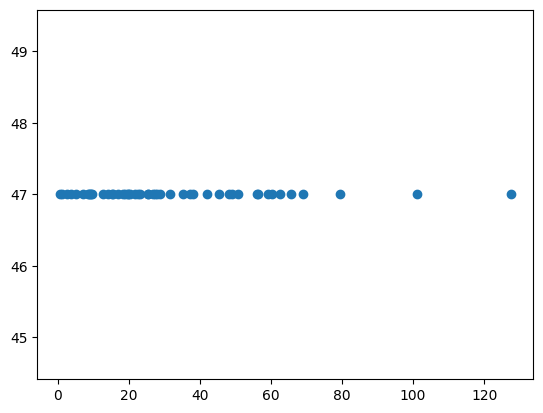

In [ ]:
cors = []
chats = []
loads = []


plt.scatter(loads, chats)

0.6964316658089713


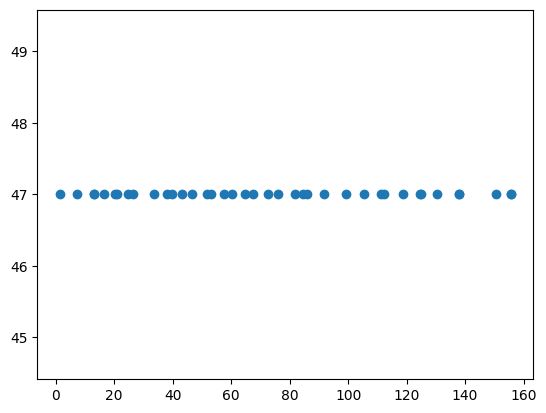

In [26]:
cors = []
chats = []
loads = []

for i in range(len(res)):
    if res[i]["analyte"] == "12-Tricosanone":
        cors.append(res[i]["ref_corr"])    
        chats.append(res[i]["c"])
        loads.append(res[i]["load"])
        
print(np.mean(cors))
plt.scatter(loads, chats)

0.6302440043514226


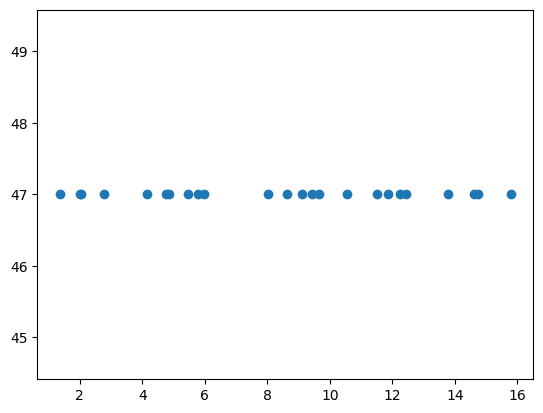

In [27]:
cors = []
chats = []
loads = []

for i in range(len(res)):
    if res[i]["analyte"] == "Suberic Acid":
        cors.append(res[i]["ref_corr"])    
        chats.append(res[i]["c"])
        loads.append(res[i]["load"])
        
print(np.mean(cors))
plt.scatter(loads, chats)

0.5604555628999661


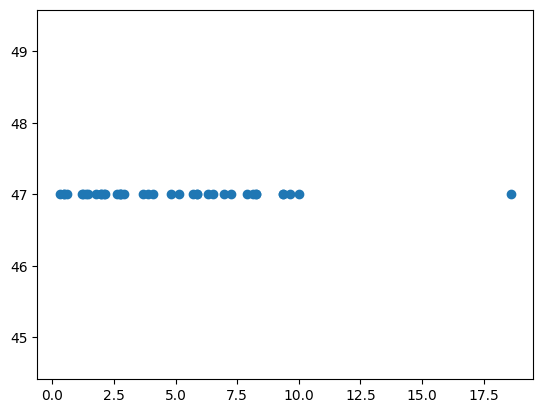

In [28]:
cors = []
chats = []
loads = []

for i in range(len(res)):
    if res[i]["analyte"] == "levoglucosan":
        cors.append(res[i]["ref_corr"])    
        chats.append(res[i]["c"])
        loads.append(res[i]["load"])
        
print(np.mean(cors))
plt.scatter(loads, chats)

In [ ]:
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]

In [89]:
res[0]

{'sample_id': '01033.dpt',
 'absorbance': array([ 2.64029971e-03,  2.39709507e-03,  1.89290221e-03, ...,
         3.86070226e-05,  6.31938885e-06, -2.55723500e-05], shape=(2785,)),
 'time': 5.097945213317871,
 'sigma': np.float64(3.5968595361466864e-05),
 'tau': np.float64(0.030198806401602118),
 'c': np.int64(49),
 'x': array([ 1.35763085e-01, -3.96572420e+00, -2.29201089e+00, -6.20726754e-02,
         1.77907398e+00,  1.16961186e+00,  5.90118247e+00, -5.33995209e+00,
         5.07294075e+00, -2.76522166e+00, -4.85110868e+00,  3.44753493e+00,
        -1.79480009e+00,  1.65487497e+00, -3.18559222e+00, -5.65466598e+00,
        -6.21824706e+00, -7.47071321e+00,  3.49558878e+00, -5.62684854e-01,
        -2.75707582e+00, -4.83034112e+00,  8.93686816e+00,  2.21093259e+00,
         6.14400511e+00,  4.41016769e+00, -4.17591256e+00,  1.32856341e-02,
        -5.14829635e-03, -2.01028407e+00, -1.28560576e+00, -8.89816367e-01,
        -5.59999008e-01,  1.25304478e+00, -5.02866218e-02, -2.08694331

In [79]:
np.unique(loads["compounds"])

array(['1-Docosanol', '1-Docosanol|Adipic Acid',
       '1-Docosanol|Adipic Acid|Suberic Acid', '1-Docosanol|Suberic Acid',
       '12-Tricosanone', 'Ammonium sulfate', 'Arachidyl Dodecanoate',
       'D-Glucose', 'Malonic Acid', 'Suberic Acid', 'fructose',
       'levoglucosan'], dtype=object)

In [86]:
ref_prof['levoglucosan']

array([[3.89724265e+02, 1.09251018e-01],
       [3.95700572e+02, 1.10828262e-01],
       [4.01676879e+02, 1.17193572e-01],
       [4.07653186e+02, 1.23558881e-01],
       [4.13629493e+02, 1.21944083e-01],
       [4.19605801e+02, 1.13945198e-01],
       [4.25582108e+02, 1.15522443e-01],
       [4.31558415e+02, 1.20291731e-01],
       [4.37534722e+02, 1.23464997e-01],
       [4.43511029e+02, 1.29830306e-01],
       [4.49487337e+02, 1.39387659e-01],
       [4.55463644e+02, 1.48945011e-01],
       [4.61439951e+02, 1.63290428e-01],
       [4.67416258e+02, 1.77635844e-01],
       [4.73392565e+02, 1.93577283e-01],
       [4.79368873e+02, 2.27074957e-01],
       [4.85345180e+02, 2.35036288e-01],
       [4.91321487e+02, 2.06289124e-01],
       [4.97297794e+02, 1.72753896e-01],
       [5.03274101e+02, 1.63158991e-01],
       [5.15226716e+02, 1.63121437e-01],
       [5.21203023e+02, 1.63102660e-01],
       [5.27179330e+02, 1.66275927e-01],
       [5.33155637e+02, 1.69449193e-01],
       [5.391319

In [85]:
ref_prof['D-Glucose']

array([[4.04961032e+02, 1.47363620e-02],
       [4.10985499e+02, 2.76534605e-02],
       [4.16821188e+02, 3.44750902e-03],
       ...,
       [3.98017863e+03, 4.66395985e-03],
       [3.98613743e+03, 4.66869312e-03],
       [3.99803863e+03, 1.45006836e-03]], shape=(544, 2))

In [84]:
ref_prof['fructose']

array([[4.63207509e+02, 3.56857667e-01],
       [4.69088680e+02, 3.58454578e-01],
       [4.74969850e+02, 3.63254580e-01],
       [4.80851021e+02, 3.66453036e-01],
       [4.86732192e+02, 3.69651492e-01],
       [4.92613362e+02, 3.72849948e-01],
       [4.98494533e+02, 3.79251496e-01],
       [5.04375703e+02, 3.92059227e-01],
       [5.10256874e+02, 3.93656138e-01],
       [5.16138045e+02, 3.85643773e-01],
       [5.22019215e+02, 3.74428317e-01],
       [5.27900386e+02, 3.72822136e-01],
       [5.33781557e+02, 3.69614409e-01],
       [5.39662727e+02, 3.69609773e-01],
       [5.57306239e+02, 3.69595867e-01],
       [5.63187410e+02, 3.71192777e-01],
       [5.69068580e+02, 3.77594325e-01],
       [5.74949751e+02, 3.85597419e-01],
       [5.80830921e+02, 3.83991238e-01],
       [5.86712092e+02, 3.79181965e-01],
       [5.92593263e+02, 3.79177329e-01],
       [5.98474433e+02, 3.80774240e-01],
       [6.04355604e+02, 3.88777333e-01],
       [6.10236774e+02, 3.88772698e-01],
       [6.161179

In [83]:
ref_prof['Malonic Acid']

array([[3.99632633e+02, 5.02558896e-03],
       [4.05674166e+02, 1.94814564e-02],
       [4.11797898e+02, 4.99941590e-02],
       ...,
       [3.94436063e+03, 7.82669326e-03],
       [3.95032818e+03, 7.83140893e-03],
       [3.95629574e+03, 7.83612459e-03]], shape=(520, 2))

In [82]:
ref_prof['Suberic Acid']

array([[3.98706336e+02, 5.96669312e-02],
       [4.04763340e+02, 4.19636080e-02],
       [4.10789109e+02, 3.04404113e-02],
       ...,
       [3.96752206e+03, 1.37733184e-02],
       [3.97348947e+03, 1.37972002e-02],
       [3.98542430e+03, 1.38449637e-02]], shape=(514, 2))

In [81]:
ref_prof['12-Tricosanone']

array([[4.75273343e+02, 1.07741933e-02],
       [4.81154466e+02, 1.07647997e-02],
       [5.04695163e+02, 1.39726985e-02],
       [5.10584387e+02, 1.55860414e-02],
       [5.16473611e+02, 1.71993844e-02],
       [5.51760354e+02, 1.71430231e-02],
       [5.57641477e+02, 1.71336295e-02],
       [5.63522601e+02, 1.71242359e-02],
       [5.75301050e+02, 2.03509218e-02],
       [5.81182174e+02, 2.03415283e-02],
       [5.87063297e+02, 2.03321347e-02],
       [5.92928220e+02, 1.70772682e-02],
       [5.98809343e+02, 1.70678746e-02],
       [6.04690467e+02, 1.70584811e-02],
       [6.34096086e+02, 1.70115133e-02],
       [6.39977209e+02, 1.70021197e-02],
       [6.69382828e+02, 1.69551520e-02],
       [6.75263952e+02, 1.69457584e-02],
       [6.87042401e+02, 2.01724443e-02],
       [6.92931625e+02, 2.17857873e-02],
       [6.98837051e+02, 2.66446032e-02],
       [7.04823484e+02, 4.77307842e-02],
       [7.11437723e+02, 1.94579044e-01],
       [7.17318847e+02, 1.94569650e-01],
       [7.231351

In [80]:
ref_prof["Ammonium sulfate"]

array([[5.90000000e+02, 4.11161657e-03],
       [5.92000000e+02, 5.19834544e-03],
       [5.94000000e+02, 8.63030508e-03],
       ...,
       [3.99400000e+03, 1.14930890e-05],
       [3.99600000e+03, 8.53555458e-06],
       [3.99800000e+03, 1.74804192e-05]], shape=(1705, 2))

In [ ]:
info

{'CO2': array([[4.19127000e+02, 3.08920092e-10],
        [4.20413000e+02, 3.61852635e-10],
        [4.21699000e+02, 3.54775280e-10],
        ...,
        [3.99585200e+03, 1.42699595e-08],
        [3.99713800e+03, 1.33072754e-08],
        [3.99842300e+03, 1.12694056e-08]], shape=(2785, 2)),
 '12-Tricosanone': array([[4.75273343e+02, 1.07741933e-02],
        [4.81154466e+02, 1.07647997e-02],
        [5.04695163e+02, 1.39726985e-02],
        [5.10584387e+02, 1.55860414e-02],
        [5.16473611e+02, 1.71993844e-02],
        [5.51760354e+02, 1.71430231e-02],
        [5.57641477e+02, 1.71336295e-02],
        [5.63522601e+02, 1.71242359e-02],
        [5.75301050e+02, 2.03509218e-02],
        [5.81182174e+02, 2.03415283e-02],
        [5.87063297e+02, 2.03321347e-02],
        [5.92928220e+02, 1.70772682e-02],
        [5.98809343e+02, 1.70678746e-02],
        [6.04690467e+02, 1.70584811e-02],
        [6.34096086e+02, 1.70115133e-02],
        [6.39977209e+02, 1.70021197e-02],
        [6.69382828

In [75]:
res[i]

{'sample_id': '01033.dpt',
 'absorbance': array([ 2.64029971e-03,  2.39709507e-03,  1.89290221e-03, ...,
         3.86070226e-05,  6.31938885e-06, -2.55723500e-05], shape=(2785,)),
 'time': 5.097945213317871,
 'sigma': np.float64(3.5968595361466864e-05),
 'tau': np.float64(0.030198806401602118),
 'c': np.int64(49),
 'x': array([ 1.35763085e-01, -3.96572420e+00, -2.29201089e+00, -6.20726754e-02,
         1.77907398e+00,  1.16961186e+00,  5.90118247e+00, -5.33995209e+00,
         5.07294075e+00, -2.76522166e+00, -4.85110868e+00,  3.44753493e+00,
        -1.79480009e+00,  1.65487497e+00, -3.18559222e+00, -5.65466598e+00,
        -6.21824706e+00, -7.47071321e+00,  3.49558878e+00, -5.62684854e-01,
        -2.75707582e+00, -4.83034112e+00,  8.93686816e+00,  2.21093259e+00,
         6.14400511e+00,  4.41016769e+00, -4.17591256e+00,  1.32856341e-02,
        -5.14829635e-03, -2.01028407e+00, -1.28560576e+00, -8.89816367e-01,
        -5.59999008e-01,  1.25304478e+00, -5.02866218e-02, -2.08694331

In [69]:
ref_prof

{'CO2': array([[4.19127000e+02, 3.08920092e-10],
        [4.20413000e+02, 3.61852635e-10],
        [4.21699000e+02, 3.54775280e-10],
        ...,
        [3.99585200e+03, 1.42699595e-08],
        [3.99713800e+03, 1.33072754e-08],
        [3.99842300e+03, 1.12694056e-08]], shape=(2785, 2)),
 '12-Tricosanone': array([[4.75273343e+02, 1.07741933e-02],
        [4.81154466e+02, 1.07647997e-02],
        [5.04695163e+02, 1.39726985e-02],
        [5.10584387e+02, 1.55860414e-02],
        [5.16473611e+02, 1.71993844e-02],
        [5.51760354e+02, 1.71430231e-02],
        [5.57641477e+02, 1.71336295e-02],
        [5.63522601e+02, 1.71242359e-02],
        [5.75301050e+02, 2.03509218e-02],
        [5.81182174e+02, 2.03415283e-02],
        [5.87063297e+02, 2.03321347e-02],
        [5.92928220e+02, 1.70772682e-02],
        [5.98809343e+02, 1.70678746e-02],
        [6.04690467e+02, 1.70584811e-02],
        [6.34096086e+02, 1.70115133e-02],
        [6.39977209e+02, 1.70021197e-02],
        [6.69382828

compounds    1-Docosanol
TRset        calibration
AS                   0.0
OC              5.758121
cCOH                 0.0
CO                   0.0
aCH             0.980681
aCOH            0.021793
Name: 01033.dpt, dtype: object

### MAP - ALS

In [7]:
with open(f"../data/corrections/teflon/map/als/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [28]:
with open(f"../data/pfte/lab_samples/map/ALS_c_loo_tau_0.1.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma"]["Ammonium sulfate"]["mean"])

93.58823702446904
93.58823702446904


In [33]:
with open(f"../data/pfte/lab_samples/map/ALS_c_loo_tau_bcv.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau"]["Ammonium sulfate"]["mean"])

93.14562123512209
93.14562123512209


In [34]:
with open(f"../data/pfte/lab_samples/map/ALS_c_bcv_tau_0.1.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))

91.34786190486362


In [35]:
with open(f"../data/pfte/lab_samples/map/ALS_c_bcv_tau_bcv.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))

90.08671768418667


### MAP - PB

In [36]:
with open(f"../data/corrections/teflon/map/pb/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [37]:
with open(f"../data/pfte/lab_samples/map/PB_c_loo_tau_0.1.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma"]["Ammonium sulfate"]["mean"])

96.01214212314153
96.01214212313997


In [38]:
with open(f"../data/pfte/lab_samples/map/PB_c_loo_tau_bcv.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau"]["Ammonium sulfate"]["mean"])

96.57452233080316
96.57452233080338


In [ ]:
bb

### EBS - ALS

In [33]:
with open(f"../data/corrections/teflon/ebs/als/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [37]:
with open(f"../data/teflon/SO4/ebs/ALS_c_loo_tau_0.1.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["fixed"]["Ammonium sulfate"]["mean"])

63.49006380681885
63.49006380681883


In [38]:
with open(f"../data/teflon/SO4/ebs/ALS_c_loo_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["tau"]["Ammonium sulfate"]["mean"])

67.96332383263002
67.96332383262997


In [39]:
with open(f"../data/teflon/SO4/ebs/ALS_c_bcv_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["c_tau"]["Ammonium sulfate"]["mean"])

91.2752207645272
85.42056511339155


### EBS - PB

In [44]:
with open(f"../data/corrections/teflon/ebs/pb/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [45]:
with open(f"../data/teflon/SO4/ebs/PB_c_loo_tau_0.1.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["fixed"]["Ammonium sulfate"]["mean"])

81.2519041371399
81.25190413714046


In [46]:
with open(f"../data/teflon/SO4/ebs/PB_c_loo_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["tau"]["Ammonium sulfate"]["mean"])

90.83691716652694
90.83691716652083


In [47]:
with open(f"../data/teflon/SO4/ebs/PB_c_bcv_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["c_tau"]["Ammonium sulfate"]["mean"])

83.94839615853759
83.94839615853816


### VIBES - ALS

In [18]:
with open(f"../data/corrections/teflon/veb/als/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [19]:
with open(f"../data/teflon/SO4/vibes/ALS_c_loo_tau_0.1_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
      
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma"]["Ammonium sulfate"]["mean"])

95.64337479814344
95.64337479814344


In [20]:
with open(f"../data/teflon/SO4/vibes/ALS_c_loo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
      
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau"]["Ammonium sulfate"]["mean"])

96.75152722634233
96.75152722634235


In [21]:
with open(f"../data/teflon/SO4/vibes/ALS_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
      
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau_c"]["Ammonium sulfate"]["mean"])

96.72707000748024
96.71174442627968


### VIBES - PB

In [45]:
with open(f"../data/corrections/teflon/veb/pb/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)


In [23]:
with open(f"../data/teflon/SO4/vibes/PB_c_loo_tau_0.1_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
      
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma"]["Ammonium sulfate"]["mean"])

97.7879202700439
97.78792027004391


In [24]:
with open(f"../data/teflon/SO4/vibes/PB_c_loo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau"]["Ammonium sulfate"]["mean"])

97.74868233206254
97.74868233206253


In [42]:
with open(f"../data/pfte/lab_samples/vibes/PB_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau_c"]["Ammonium sulfate"]["mean"])

32.06838081879964


KeyError: 'sigma_tau_c'

In [47]:
with open(f"../data/pfte/lab_samples/vibes/PB_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau_c"]["Ammonium sulfate"]["mean"])

97.75074661673567
97.68375538971836


In [48]:
with open(f"../data/pfte/lab_samples/vibes/PB_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)

In [53]:
chats = []
for i in res:
    chats.append(i["c"])

{'whiskers': [<matplotlib.lines.Line2D at 0x27a37302b10>,
 'caps': [<matplotlib.lines.Line2D at 0x27a37302c90>,
 'boxes': [<matplotlib.lines.Line2D at 0x27a35bed490>],
 'medians': [<matplotlib.lines.Line2D at 0x27a374090d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x27a3740b080>],
 'means': []}

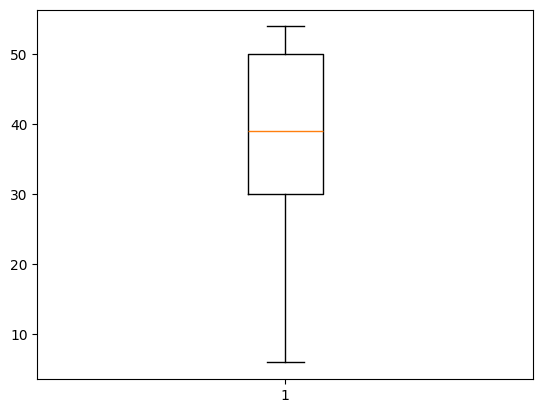

In [54]:
plt.boxplot(chats)

In [ ]:
# with open(f"../data/corrections/teflon/veb/als/corr_metrics.pkl", "rb") as f:
#     metrics = pickle.load(f)    

### EBS-ALS

In [107]:
c_grid = np.arange(1,54)
tau_grid = np.array([0.025,0.05,0.1,0.2,0.4])

for c, tau in itertools.product(c_grid, tau_grid):
    with open(f"../data/teflon/SO4/ebs/grid/ALS/c_{c}_tau_{tau}.pkl", "rb") as f:
        res = pickle.load(f)
        
    for i in res:
        a = i["absorbance"]
        id =  i["sample_id"]
        i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
        i["load"] = loads.loc[id]["AS"]
       
    with open(f"../data/teflon/SO4/ebs/grid/ALS/c_{c}_tau_{tau}.pkl", "wb") as f:
        pickle.dump(res, f)
    

In [148]:
metrics_dict = []
for c, tau in itertools.product(c_grid, tau_grid):
    with open(f"../data/teflon/SO4/ebs/grid/ALS/c_{c}_tau_{tau}.pkl", "rb") as f:
        res = pickle.load(f)
    
    _,R2 = comp_simple_preds(res)
    
    metrics_dict.append({"c": c, "tau": tau, "mean_ref_corr": np.mean([i["ref_corr"] for i in res]), "se_ref_corr": np.std([i["ref_corr"] for i in res])/np.sqrt(len(res)), "R2": R2})

In [159]:
metrics_df = pd.DataFrame(metrics_dict)
metrics_df.to_csv("../data/temp/metrics_df.csv", index=False)